In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2469 entries, 2007-06-29 to 2017-06-26
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SP500   2469 non-null   float64
 1   Bonds   2469 non-null   float64
 2   Gold    2469 non-null   float64
 3   Oil     2469 non-null   float64
dtypes: float64(4)
memory usage: 96.4 KB
None


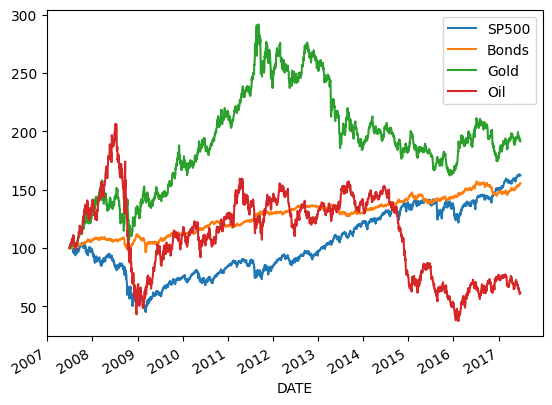

In [2]:
# Import data here
prices = pd.read_csv('../Data/stock_data/asset_classes.csv', parse_dates = ['DATE'], index_col = 'DATE')

# Inspect prices here
print(prices.info())

# Select first prices
first_prices = prices.iloc[0]

# Create normalized
normalized = prices.div(first_prices).mul(100)

# Plot normalized
normalized.plot()
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1762 entries, 2010-01-04 to 2016-12-30
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   JNJ     1762 non-null   float64
 1   JPM     1762 non-null   float64
 2   XOM     1762 non-null   float64
 3   DJIA    1762 non-null   float64
dtypes: float64(4)
memory usage: 68.8 KB
None


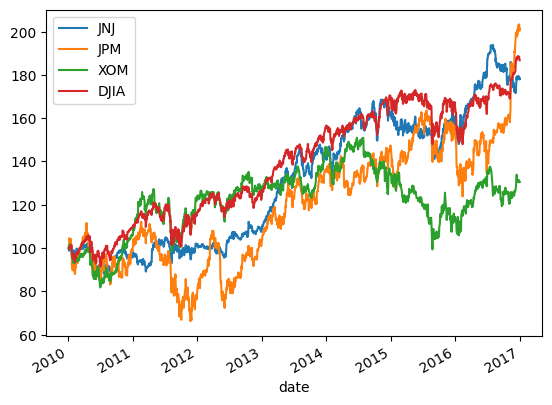

In [3]:
# Import stock prices and index here
stocks = pd.read_csv('../Data/stock_data/nyse.csv', parse_dates = ['date'], index_col = 'date')
dow_jones = pd.read_csv('../Data/stock_data/dow_jones.csv', parse_dates = ['date'], index_col = 'date')

# Concatenate data and inspect result here
data = pd.concat([stocks, dow_jones], axis = 1).dropna()
print(data.info())

# Normalize and plot your data here
normalized = data.div(data.iloc[0]).mul(100).plot()
plt.show()

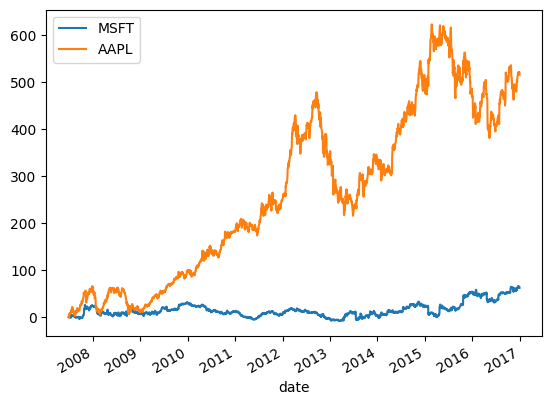

In [4]:
# Create tickers
tickers = ['MSFT', 'AAPL']

# Import stock data here
stocks = pd.read_csv('../Data/stock_data/msft_aapl.csv', parse_dates = ['date'], index_col = 'date')

# Import index here
sp500 = pd.read_csv('../Data/stock_data/sp500.csv', parse_dates = ['date'], index_col = 'date')

# Concatenate stocks and index here
data = pd.concat([sp500, stocks], axis = 1).dropna()

# Normalize data
normalized = data.div(data.iloc[0]).mul(100)

# Subtract the normalized index from the normalized stock prices, and plot the result
diff = normalized[tickers].sub(normalized['SP500'], axis = 0).plot()
plt.show()

In [5]:
# Set start and end dates
start = '2016-01-01'
end = '2016-02-29'

# Create monthly_dates here
monthly_dates = pd.date_range(start, end, freq = 'ME')

# Create and print monthly here
monthly = pd.Series(data = [1, 2], index = monthly_dates)
print(monthly)

# Create weekly_dates here
weekly_dates = pd.date_range(start, end, freq = 'W')

# Print monthly, reindexed using weekly_dates
print(monthly.reindex(weekly_dates))
print(monthly.reindex(weekly_dates, method = 'bfill'))
print(monthly.reindex(weekly_dates, method = 'ffill'))

2016-01-31    1
2016-02-29    2
Freq: ME, dtype: int64
2016-01-03    NaN
2016-01-10    NaN
2016-01-17    NaN
2016-01-24    NaN
2016-01-31    1.0
2016-02-07    NaN
2016-02-14    NaN
2016-02-21    NaN
2016-02-28    NaN
Freq: W-SUN, dtype: float64
2016-01-03    1
2016-01-10    1
2016-01-17    1
2016-01-24    1
2016-01-31    1
2016-02-07    2
2016-02-14    2
2016-02-21    2
2016-02-28    2
Freq: W-SUN, dtype: int64
2016-01-03    NaN
2016-01-10    NaN
2016-01-17    NaN
2016-01-24    NaN
2016-01-31    1.0
2016-02-07    1.0
2016-02-14    1.0
2016-02-21    1.0
2016-02-28    1.0
Freq: W-SUN, dtype: float64


            Unemployment
date                    
2010-01-03           NaN
2010-01-10           NaN
2010-01-17           NaN
2010-01-24           NaN
2010-01-31           NaN
            Unemployment
date                    
2010-01-03           9.8
2010-01-10           9.8
2010-01-17           9.8
2010-01-24           9.8
2010-01-31           9.8
            Unemployment
date                    
2010-01-03           9.8
2010-01-10           9.8
2010-01-17           9.8
2010-01-24           9.8
2010-01-31           9.8


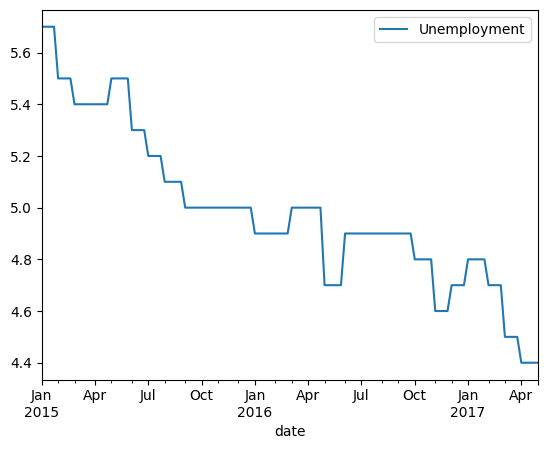

In [6]:
# Import data here
data = pd.read_csv('../Data/stock_data/debt_unemployment.csv', parse_dates = ['date'], index_col = 'date')
data = data[['Unemployment']]

# Show first five rows of weekly series
print(data.asfreq('W').head())

# Show first five rows of weekly series with bfill option
print(data.asfreq('W', method = 'bfill').head())

# Create weekly series with ffill option and show first five rows
weekly_ffill = data.asfreq('W', method = 'ffill')
print(weekly_ffill.head())

# Plot weekly_fill starting 2015 here 
weekly_ffill.loc['2015-01-01' : ].plot()
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 89 entries, 2010-01-01 to 2017-05-01
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unemployment  89 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB
None


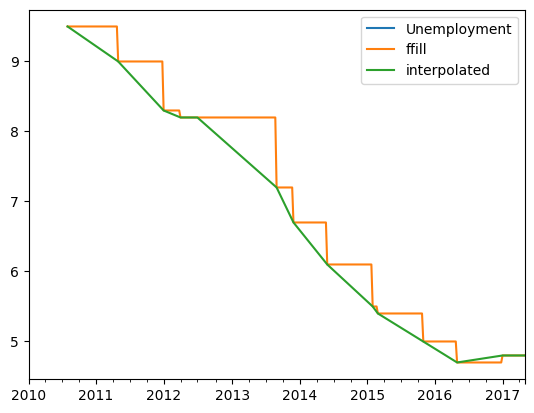

In [7]:
monthly = pd.read_csv('../Data/stock_data/debt_unemployment.csv', parse_dates = ['date'], index_col = 'date')

monthly = monthly[['Unemployment']]

# Inspect data here
print(monthly.info())

# Create weekly dates
weekly_dates = pd.date_range(monthly.index.min(), monthly.index.max(), freq = 'W')

# Reindex monthly to weekly data
weekly = monthly.reindex(weekly_dates)

# Create ffill and interpolated columns
weekly['ffill'] = weekly['Unemployment'].ffill()
weekly['interpolated'] = monthly.asfreq('W').interpolate().add_suffix('_inter')

# Plot weekly
weekly.plot()
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 89 entries, 2010-01-01 to 2017-05-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Debt/GDP      29 non-null     float64
 1   Unemployment  89 non-null     float64
dtypes: float64(2)
memory usage: 2.1 KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 89 entries, 2010-01-01 to 2017-05-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Debt/GDP      89 non-null     float64
 1   Unemployment  89 non-null     float64
dtypes: float64(2)
memory usage: 2.1 KB
None


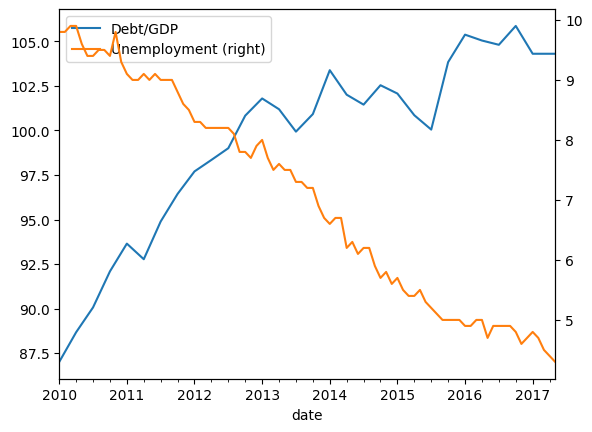

In [8]:
# Import & inspect data here
data = pd.read_csv('../Data/stock_data/debt_unemployment.csv', parse_dates = ['date'], index_col = 'date')
print(data.info())

# Interpolate and inspect here
interpolated = data.interpolate()
print(interpolated.info())

# Plot interpolated data here
interpolated.plot(secondary_y = 'Unemployment')
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6291 entries, 2000-01-01 to 2017-03-31
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Los Angeles  5488 non-null   float64
 1   New York     6167 non-null   float64
dtypes: float64(2)
memory usage: 147.4 KB
None


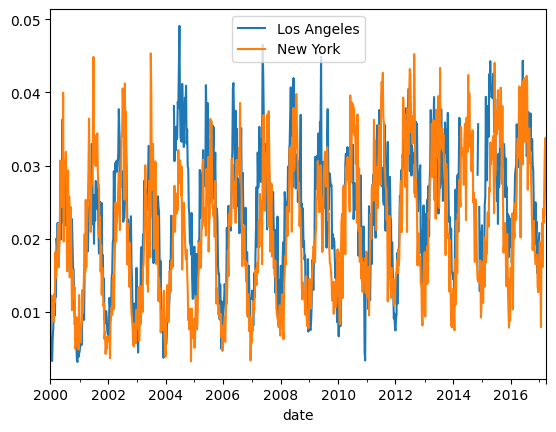

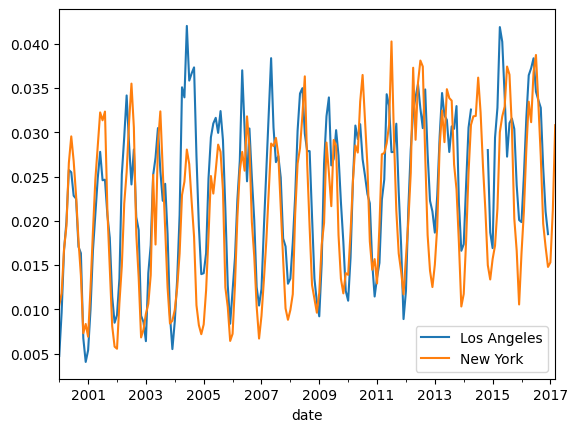

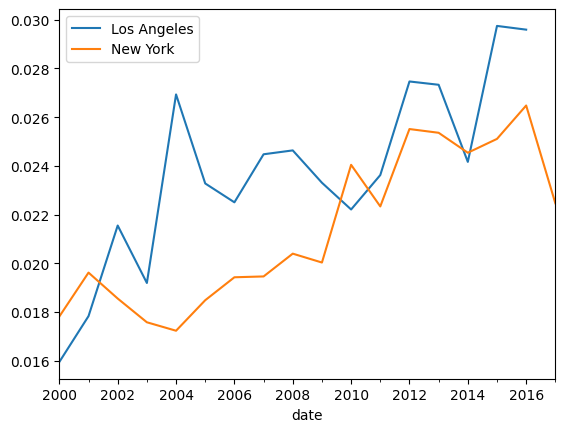

In [9]:
# Import and inspect data here
ozone = pd.read_csv('../Data/air_quality_data/ozone_nyla.csv', parse_dates = ['date'], index_col = 'date')
print(ozone.info())

# Calculate and plot the weekly average ozone trend
weekly = ozone.resample('W').mean().plot()
plt.show()

# Calculate and plot the monthly average ozone trend
monthly = ozone.resample('ME').mean().plot()
plt.show()

# Calculate and plot the annual average ozone trend
annualy = ozone.resample('YE').mean().plot()
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 504 entries, 2015-01-02 to 2016-12-30
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FB      504 non-null    float64
 1   GOOG    504 non-null    float64
dtypes: float64(2)
memory usage: 11.8 KB
None


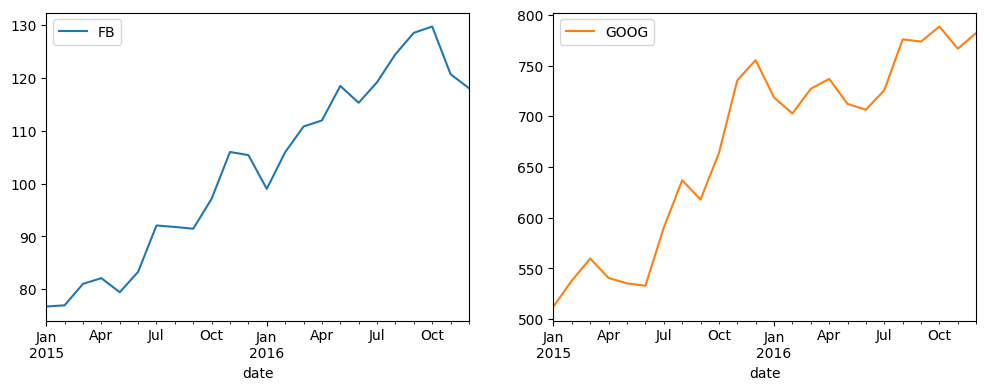

In [10]:
# Import and inspect data here
stocks = pd.read_csv('../Data/stock_data/goog_fb.csv', parse_dates = ['date'], index_col = 'date')
print(stocks.info())

# Calculate and plot the monthly averages
monthly_average = stocks.resample('ME').mean()
monthly_average.plot(subplots = True, layout = (1, 2), figsize = (12, 4))
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 41 entries, 2007-01-01 to 2017-01-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gdp_growth  41 non-null     float64
dtypes: float64(1)
memory usage: 656.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2610 entries, 2007-06-29 to 2017-06-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   djia    2519 non-null   float64
dtypes: float64(1)
memory usage: 40.8 KB
None


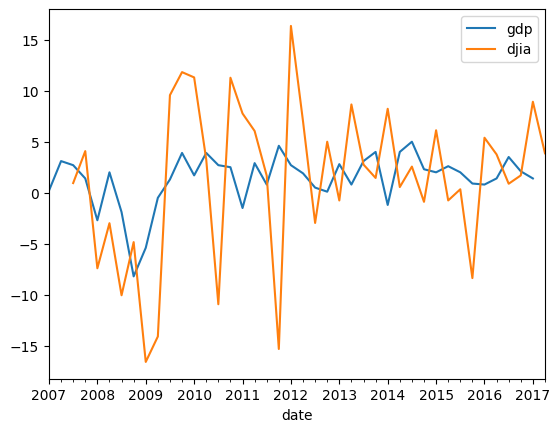

In [11]:
# Import and inspect gdp_growth here
gdp_growth = pd.read_csv('../Data/stock_data/gdp_growth.csv', parse_dates = ['date'], index_col = 'date')
print(gdp_growth.info())

# Import and inspect djia here
djia = pd.read_csv('../Data/stock_data/djia.csv', parse_dates = ['date'], index_col = 'date')
print(djia.info())

# Calculate djia quarterly returns here 
djia_quarterly = djia.resample('QS').first()
djia_quarterly_return = djia_quarterly.pct_change(periods = 1).mul(100)

# Concatenate, rename and plot djia_quarterly_return and gdp_growth here 
data = pd.concat([gdp_growth, djia_quarterly_return], axis = 1)
data.columns = ['gdp', 'djia']
data.plot()
plt.show()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2395 entries, 2007-06-29 to 2016-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SP500   2395 non-null   float64
dtypes: float64(1)
memory usage: 37.4 KB
None


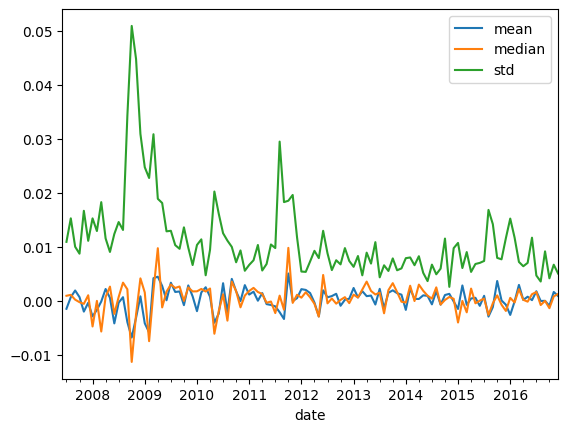

In [12]:
# Import data here
sp500 = pd.read_csv('../Data/stock_data/sp500.csv', parse_dates = ['date'], index_col = 'date')
print(sp500.info())

# Calculate daily returns here
daily_returns = sp500.squeeze().pct_change(periods = 1)

# Resample and calculate statistics
stats = daily_returns.resample('ME').agg(['mean', 'median', 'std'])

# Plot stats here
stats.plot()
plt.show()